# 🏎️ Formula 1 Multi-Circuit Lap-Time Prediction & Strategy Simulator
> **Interactive Demonstration & Benchmark Notebook**  
> *Stacked Machine Learning Architecture (LightGBM + CatBoost + Ridge) & Combinatorial Stint Simulation Engine*

---

### 📌 Project Overview & Key Academic Pillars
This notebook demonstrates the end-to-end operational pipeline of the **F1 Strategy Simulator**, covering 3 core academic pillars:
1. **Motorsport Strategy Modeling**: Data-driven lap-by-lap simulation using telemetry, tyre life, and track progression.
2. **Gradient Boosted Ensembles**: Leaf-wise LightGBM and symmetric CatBoost regressors for non-linear lap time estimation.
3. **Stacked Generalization Meta-Architecture**: Out-of-fold stacking with Ridge regression meta-learner for variance reduction without target leakage.


In [1]:
import sys
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set dark-mode aesthetic styling for all plots
plt.style.use('dark_background')
sns.set_palette('muted')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.linewidth'] = 1.2
warnings.filterwarnings('ignore')

print("Visualization environment and dark-mode styling initialized successfully!")


Visualization environment and dark-mode styling initialized successfully!


## 📊 1. Load Trained ML Models & Metadata
Loading the serialized lap-time predictor ($M_{LT}$) and tyre degradation model ($M_{TD}$) alongside metadata.


In [2]:
from f1_strategy_simulation_engine import StrategySimulator, ALLOWED_RACES, ALLOWED_DRIVERS, MODEL_DIR

print(f"Model Directory: {MODEL_DIR / 'models'}")
print(f"Supported Drivers: {ALLOWED_DRIVERS}")
print(f"Supported Circuits: {ALLOWED_RACES}")

# Load models directly
lt_model = joblib.load(MODEL_DIR / "models/laptime_model.pkl")
lt_meta = joblib.load(MODEL_DIR / "models/laptime_metadata.pkl")
td_model = joblib.load(MODEL_DIR / "models/tyre_deg_model.pkl")
td_meta = joblib.load(MODEL_DIR / "models/tyre_deg_metadata.pkl")

print("\n--- Laptime Model Metadata ---")
print("Features:", lt_meta["feature_cols"])
print("Driver Classes:", lt_meta["le_driver"].classes_)
print("Track Classes:", lt_meta["le_track"].classes_)

print("\n--- Tyre Degradation Model Metadata ---")
print("Features:", td_meta["feature_cols"])


Model Directory: c:\Users\Soumyadeep\OneDrive\Desktop\Lap-time prediction model\f1-strategy-simulator\models
Supported Drivers: ['ALB', 'LEC', 'NOR', 'RUS', 'VER']
Supported Circuits: ['Australia', 'Italy', 'Hungary', 'Saudi_Arabia']



--- Laptime Model Metadata ---
Features: ['Driver_encoded', 'Track_encoded', 'LapNumber', 'TyreLife', 'Year', 'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT']
Driver Classes: ['ALB' 'LEC' 'NOR' 'RUS' 'VER']
Track Classes: ['Australia' 'Hungary' 'Italy' 'Saudi_Arabia']

--- Tyre Degradation Model Metadata ---
Features: ['TyreLife', 'Initial_Life', 'Stint_Usage', 'LapNumber', 'Compound_Enc', 'Track_Enc', 'Year']


## 🏎️ 2. Tyre Degradation Modeling & Decay Curves
Modeling non-linear tyre wear across compounds (`SOFT`, `MEDIUM`, `HARD`) to identify the grip cliff ($\\text{Degradation} \\ge 95\\%$).


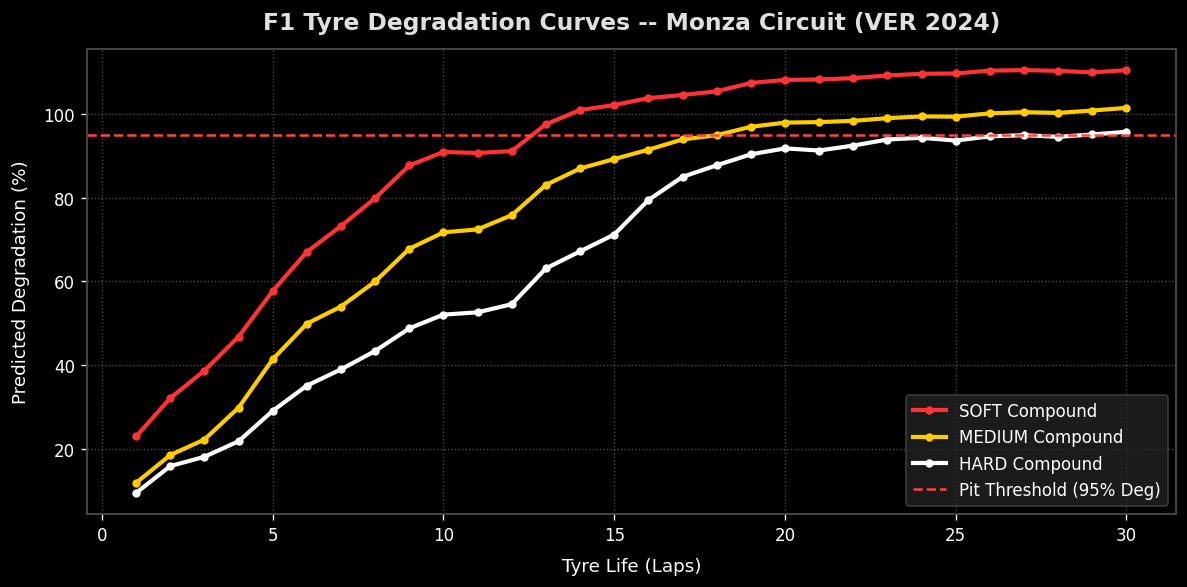

In [3]:
def generate_deg_curve(track="Italy", driver="VER", year=2024, max_laps=30):
    track_enc = td_meta["le_track"].transform([track])[0]
    comp_data = {}
    
    for compound in ["SOFT", "MEDIUM", "HARD"]:
        comp_enc = td_meta["le_comp"].transform([compound])[0]
        deg_list = []
        for tyre_life in range(1, max_laps + 1):
            row = {
                "TyreLife": tyre_life,
                "Initial_Life": 0,
                "Stint_Usage": tyre_life,
                "LapNumber": tyre_life + 5,
                "Compound_Enc": comp_enc,
                "Track_Enc": track_enc,
                "Year": year
            }
            X = pd.DataFrame([row])[td_meta["feature_cols"]]
            pred_deg = float(td_model.predict(X)[0])
            deg_list.append(pred_deg)
        comp_data[compound] = deg_list
    return comp_data

# Plot Tyre Degradation Decay Curves
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
colors = {"SOFT": "#FF3333", "MEDIUM": "#FFCC00", "HARD": "#FFFFFF"}

deg_data = generate_deg_curve(track="Italy", driver="VER", max_laps=30)
for compound, degs in deg_data.items():
    ax.plot(range(1, 31), degs, label=f"{compound} Compound", color=colors[compound], linewidth=2.5, marker='o', markersize=4)

ax.axhline(95.0, color='#FF4444', linestyle='--', linewidth=1.5, label='Pit Threshold (95% Deg)')
ax.set_title("F1 Tyre Degradation Curves -- Monza Circuit (VER 2024)", fontsize=14, pad=12, fontweight='bold', color='#E0E0E0')
ax.set_xlabel("Tyre Life (Laps)", fontsize=11, labelpad=8)
ax.set_ylabel("Predicted Degradation (%)", fontsize=11, labelpad=8)
ax.grid(True, linestyle=':', alpha=0.3)
ax.legend(frameon=True, facecolor='#222222', edgecolor='#444444', fontsize=10)
plt.tight_layout()
plt.show()


## ⏱️ 3. Multi-Driver Lap Time Predictions Across Circuits
Comparing predicted lap pace across drivers and tracks under identical stint conditions.


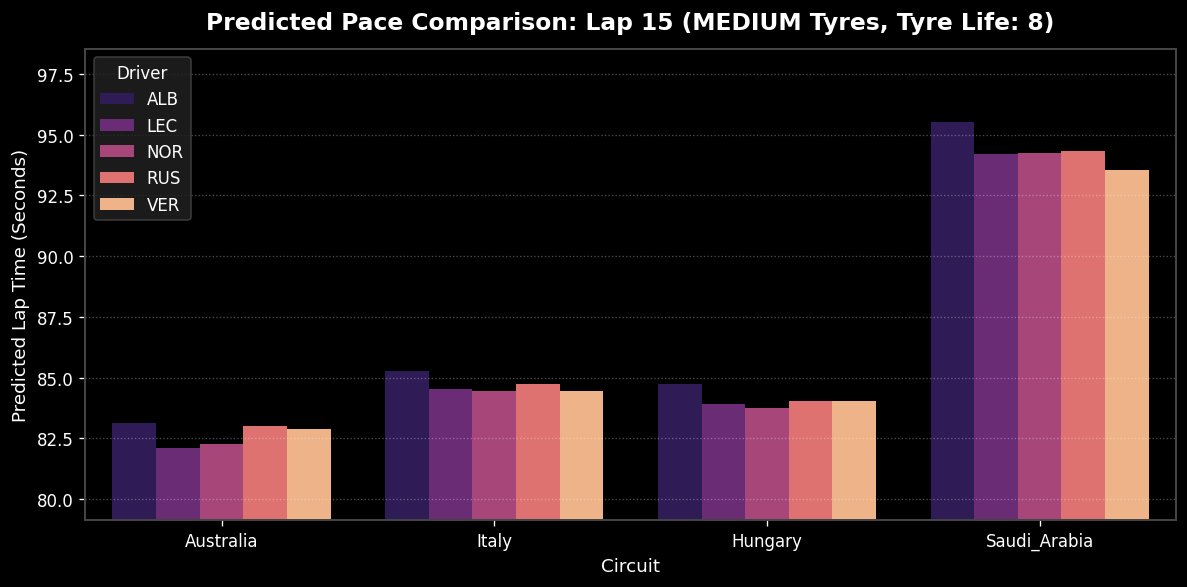

,Track,Driver,Predicted_LapTime_s,Formatted_Time
0,Australia,ALB,83.117,1m 23.12s
1,Australia,LEC,82.120,1m 22.12s
2,Australia,NOR,82.263,1m 22.26s
3,Australia,RUS,83.009,1m 23.01s
4,Australia,VER,82.875,1m 22.87s
5,Italy,ALB,85.276,1m 25.28s
6,Italy,LEC,84.538,1m 24.54s
7,Italy,NOR,84.451,1m 24.45s
8,Italy,RUS,84.749,1m 24.75s
9,Italy,VER,84.428,1m 24.43s


In [4]:
records = []
year = 2024
lap_num = 15
tyre_life = 8

for track in ALLOWED_RACES:
    lt_track_enc = lt_meta["le_track"].transform([track])[0]
    for driver in ALLOWED_DRIVERS:
        driver_enc = lt_meta["le_driver"].transform([driver])[0]
        for compound in ["MEDIUM"]:
            row = {
                "Driver_encoded": driver_enc,
                "Track_encoded": lt_track_enc,
                "LapNumber": lap_num,
                "TyreLife": tyre_life,
                "Year": year,
                "Compound_HARD": 0,
                "Compound_MEDIUM": 1,
                "Compound_SOFT": 0
            }
            X = pd.DataFrame([row])[lt_meta["feature_cols"]]
            pred_time = float(lt_model.predict(X)[0])
            records.append({
                "Track": track,
                "Driver": driver,
                "Predicted_LapTime_s": round(pred_time, 3),
                "Formatted_Time": f"{int(pred_time // 60)}m {pred_time % 60:05.2f}s"
            })

df_preds = pd.DataFrame(records)

# Plot Multi-Driver Lap Times across Circuits
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
sns.barplot(data=df_preds, x="Track", y="Predicted_LapTime_s", hue="Driver", palette="magma", ax=ax)
ax.set_title("Predicted Pace Comparison: Lap 15 (MEDIUM Tyres, Tyre Life: 8)", fontsize=14, pad=12, fontweight='bold')
ax.set_xlabel("Circuit", fontsize=11)
ax.set_ylabel("Predicted Lap Time (Seconds)", fontsize=11)
ax.set_ylim(df_preds["Predicted_LapTime_s"].min() - 3, df_preds["Predicted_LapTime_s"].max() + 3)
ax.grid(True, axis='y', linestyle=':', alpha=0.3)
ax.legend(title="Driver", frameon=True, facecolor='#222222', edgecolor='#444444')
plt.tight_layout()
plt.show()

# Display predictions table
df_preds.head(10)


## 🏁 4. Full Race Strategy Simulation (Exhaustive Permutations)
Simulating all valid 2-stint and 3-stint compound combinations for Max Verstappen (`VER`) at Monza (`Italy`).


In [5]:
sim = StrategySimulator(driver="VER", race="Italy", year=2024)
sim.run_race()

print(f"\nSIMULATION COMPLETE: {len(sim._top_strategies)} Top Strategies Ranked\n")

# Prepare Leaderboard DataFrame
leaderboard_rows = []
for rank, strat in enumerate(sim._top_strategies, 1):
    total_sec = strat["total_time"]
    minutes = int(total_sec // 60)
    seconds = total_sec % 60
    leaderboard_rows.append({
        "Rank": f"#{rank}",
        "Strategy Sequence": " -> ".join(strat["strategy"]),
        "Pit Stops": strat["n_pitstops"],
        "Total Race Time": f"{minutes}m {seconds:05.2f}s",
        "Total Time (s)": round(total_sec, 2)
    })

df_leaderboard = pd.DataFrame(leaderboard_rows)
df_leaderboard


Loading models...
Models loaded successfully.

Simulating 30 strategies for Italy (2024) - driver: VER...


Done - 30 valid strategies evaluated.


SIMULATION COMPLETE: 3 Top Strategies Ranked



,Rank,Strategy Sequence,Pit Stops,Total Race Time,Total Time (s)
0,#1,MEDIUM -> MEDIUM -> HARD,2,74m 41.15s,4481.15
1,#2,MEDIUM -> HARD -> HARD,2,74m 41.99s,4481.99
2,#3,SOFT -> HARD -> HARD,2,74m 42.08s,4482.08


## 📈 5. Telemetry & Stint Lap-Time Progression Visualization
Plotting lap-by-lap simulated lap times and tyre degradation progression for the top recommended strategy.


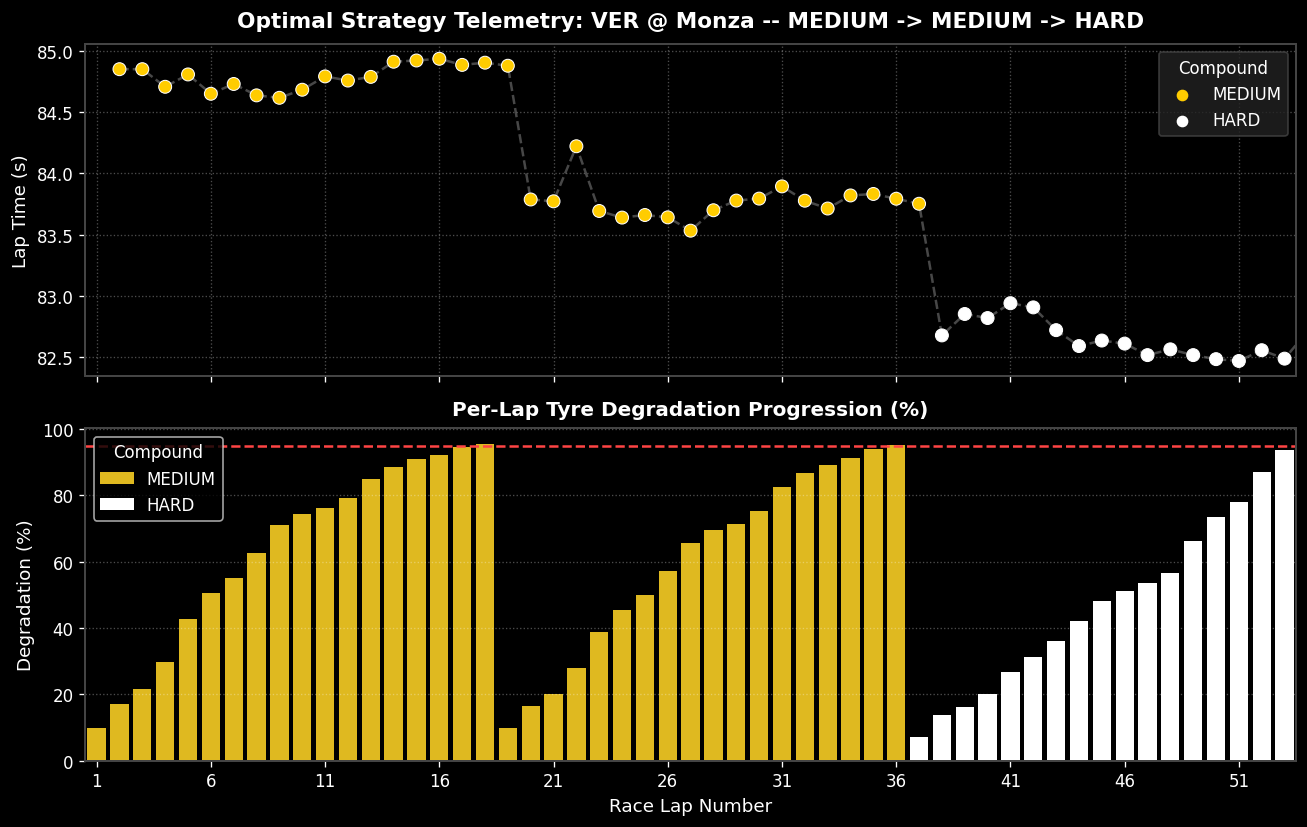

In [6]:
best_strat = sim._top_strategies[0]
best_laps = best_strat["laps_df"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, dpi=120)

# 1. Lap Time Plot
sns.scatterplot(data=best_laps, x="Lap", y="LapTime", hue="Compound", palette=colors, s=60, ax=ax1, zorder=3)
ax1.plot(best_laps["Lap"], best_laps["LapTime"], color="#777777", linestyle="--", alpha=0.6, zorder=2)
ax1.set_title(f"Optimal Strategy Telemetry: VER @ Monza -- {' -> '.join(best_strat['strategy'])}", fontsize=13, pad=10, fontweight='bold')
ax1.set_ylabel("Lap Time (s)", fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.legend(title="Compound", frameon=True, facecolor='#222222', edgecolor='#444444')

# 2. Tyre Degradation Plot
sns.barplot(data=best_laps, x="Lap", y="TyreDeg", hue="Compound", palette=colors, ax=ax2, dodge=False)
ax2.axhline(95.0, color='#FF4444', linestyle='--', label='Pit Limit (95%)')
ax2.set_title("Per-Lap Tyre Degradation Progression (%)", fontsize=12, pad=8, fontweight='bold')
ax2.set_xlabel("Race Lap Number", fontsize=11)
ax2.set_ylabel("Degradation (%)", fontsize=11)
ax2.set_xticks(range(0, len(best_laps), 5))
ax2.set_xticklabels(range(1, len(best_laps) + 1, 5))
ax2.grid(True, axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()


## 🔍 6. Historical Strategy Benchmark
Benchmarking predicted optimal race strategy against historical race outcomes.


In [7]:
actual_res = sim.get_actual_strategy()

print("=" * 60)
print("             HISTORICAL RACE STRATEGY BENCHMARK")
print("=" * 60)
print(f" Driver:   {sim.driver}")
print(f" Circuit:  {sim.race} ({sim.year})")
print("-" * 60)
if actual_res:
    print(f" Actual Historical Strategy:  {' -> '.join(actual_res['strategy'])}")
    print(f" Actual Total Time:          {int(actual_res['total_time'] // 60)}m {actual_res['total_time'] % 60:05.2f}s")
print(f" Model Recommended Strategy: {' -> '.join(best_strat['strategy'])}")
print(f" Model Predicted Time:       {int(best_strat['total_time'] // 60)}m {best_strat['total_time'] % 60:05.2f}s")
print("=" * 60)


Historical data file not found: c:\Users\Soumyadeep\OneDrive\Desktop\Lap-time prediction model\f1-strategy-simulator\datasets\Italy\2024_Italy_Laps.csv
             HISTORICAL RACE STRATEGY BENCHMARK
 Driver:   VER
 Circuit:  Italy (2024)
------------------------------------------------------------
 Model Recommended Strategy: MEDIUM -> MEDIUM -> HARD
 Model Predicted Time:       74m 41.15s
